In [ ]:
# Setup environment
!pip install kaggle tensorflow opencv-python-headless numpy visualkeras keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 997.4/997.4 kB 33.3 MB/s eta 0:00:00


In [ ]:
# Enhanced Distracted Driver Detection
# Adding Hyperparameter Tuning, Transfer Learning, and K-Fold Validation

# Import necessary libraries
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import KFold
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import random
from PIL import Image
import keras_tuner as kt
import visualkeras
import shutil

In [ ]:
# Setup Kaggle API
from google.colab import files
files.upload()  # Upload kaggle.json


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"aisarath","key":"7a4e842079e176e9d510f38c0b5904c2"}'}

In [ ]:
! mkdir -p ~/.kaggle
! cp kaggle.json ~/.kaggle/
! chmod 600 ~/.kaggle/kaggle.json

# Download the dataset
! kaggle competitions download -c state-farm-distracted-driver-detection --force

# Extract the dataset
import zipfile
with zipfile.ZipFile('state-farm-distracted-driver-detection.zip', 'r') as zip_ref:
    zip_ref.extractall('state_farm_dataset')


 99% 3.97G/4.00G [00:54<00:00, 47.6MB/s]
100% 4.00G/4.00G [00:55<00:00, 78.0MB/s]


<ipython-input-6-689caa1f7eca>:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  selected_images = df_driver.groupby("classname").apply(lambda x: x.sample(n=200, random_state=42)).reset_index(drop=True)


✅ Dataset reduced successfully!


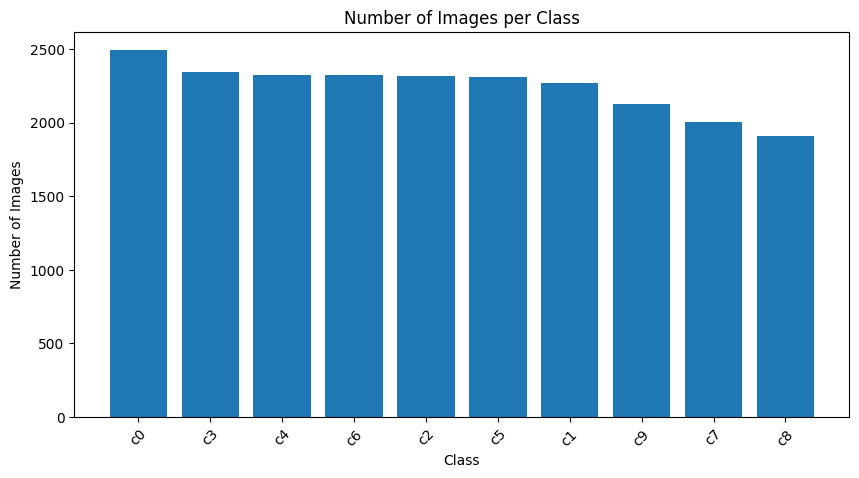

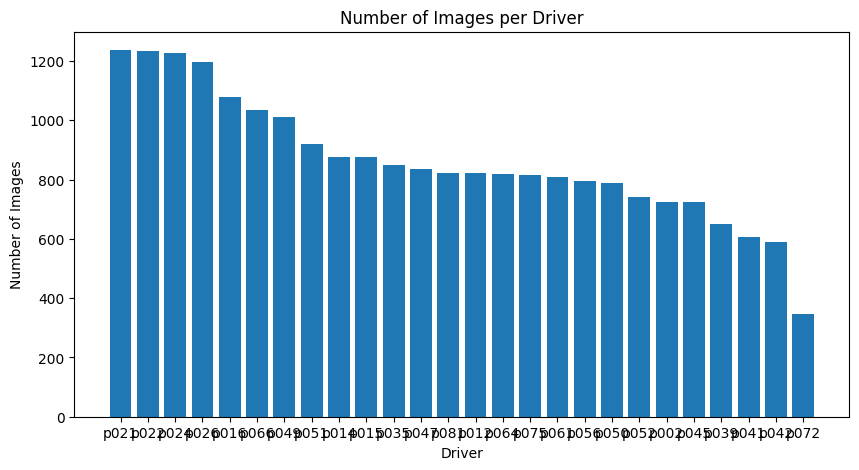

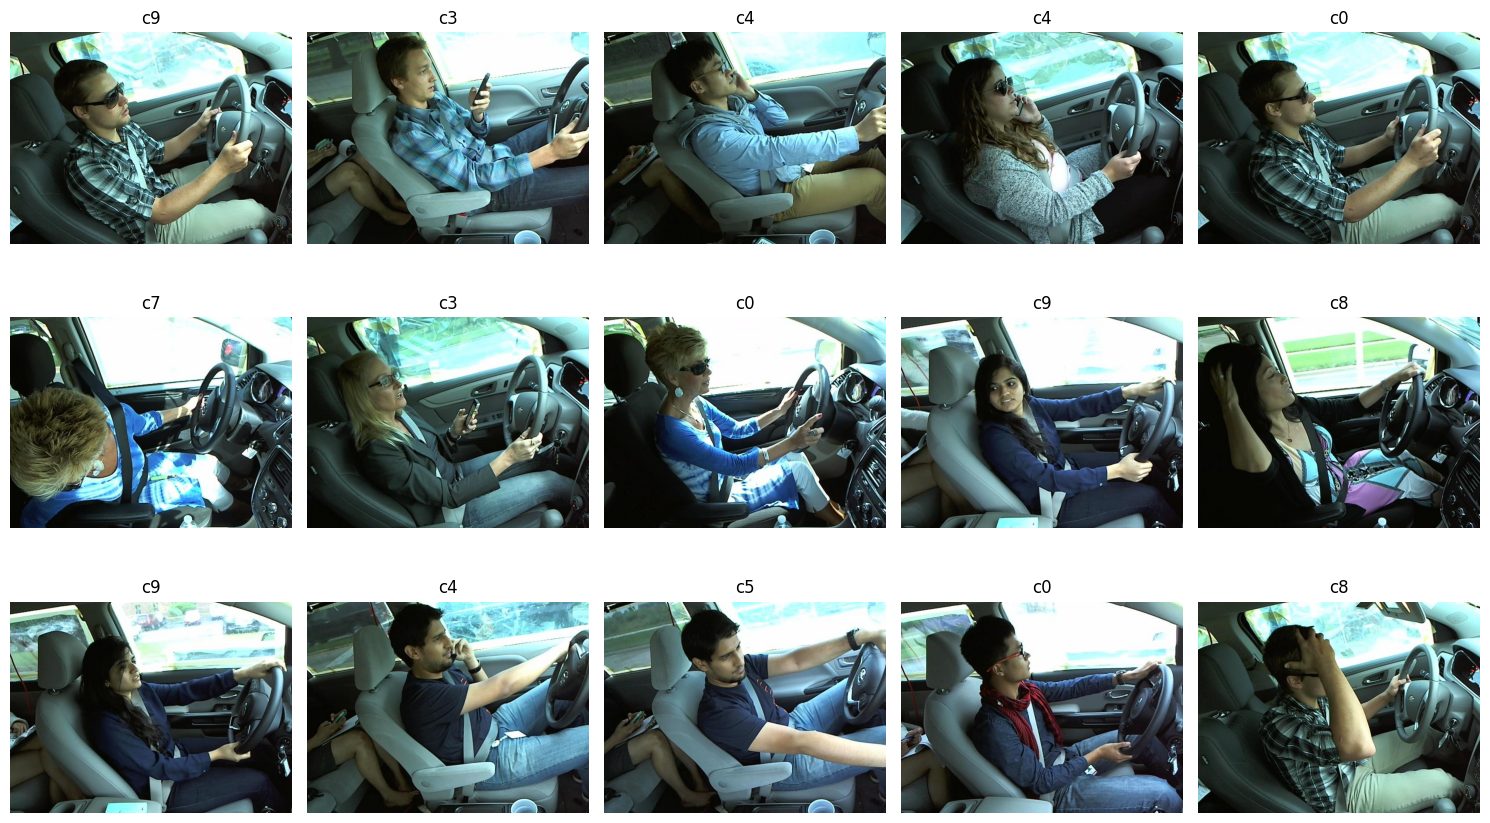


--- Creating Transfer Learning Model with MobileNetV2 ---
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Found 1600 images belonging to 10 classes.
Found 400 images belonging to 10 classes.


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 70s 745ms/step - accuracy: 0.1223 - loss: 3.1862 - val_accuracy: 0.1350 - val_loss: 2.4749 - learning_rate: 1.0000e-04
Epoch 2/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 29s 585ms/step - accuracy: 0.1832 - loss: 2.8558 - val_accuracy: 0.1925 - val_loss: 2.3372 - learning_rate: 1.0000e-04
Epoch 3/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 30s 606ms/step - accuracy: 0.2410 - loss: 2.4990 - val_accuracy: 0.2275 - val_loss: 2.2521 - learning_rate: 1.0000e-04
Epoch 4/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 40s 584ms/step - accuracy: 0.3236 - loss: 2.0400 - val_accuracy: 0.3200 - val_loss: 1.9923 - learning_rate: 1.0000e-04
Epoch 5/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 42s 608ms/step - accuracy: 0.4298 - loss: 1.7098 - val_accuracy: 0.3600 - val_loss: 1.8319 - learning_rate: 1.0000e-04
Epoch 6/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 40s 586ms/step - accuracy: 0.4938 - loss: 1.4940 - val_accuracy: 0.4350 - val_loss: 1.5814 - learning_rate: 1.0000e-04
Epoch 7/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 29s 586ms/step - acc

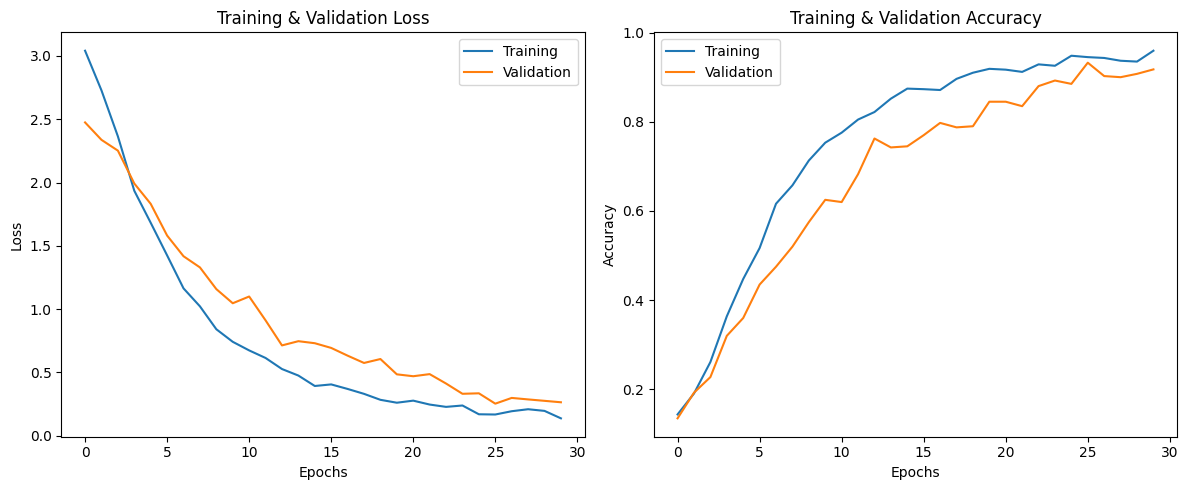


--- Evaluating Transfer Learning Model ---
Found 2000 images belonging to 10 classes.
63/63 ━━━━━━━━━━━━━━━━━━━━ 12s 148ms/step

Accuracy: 96.15%

Detailed Classification Report:
                          precision  recall  f1-score  support
Safe Driving                  94.82   91.50     93.13   200.00
Texting Right                100.00   90.00     94.74   200.00
Talking on Phone - Right      99.00   99.00     99.00   200.00
Texting Left                  98.99   98.00     98.49   200.00
Talking on Phone - Left       99.49   98.00     98.74   200.00
Operating Radio               89.64   99.50     94.31   200.00
Drinking                      94.66   97.50     96.06   200.00
Reaching Behind               98.51   99.00     98.75   200.00
Hair & Makeup                 97.87   92.00     94.85   200.00
Talking to Passenger          90.23   97.00     93.49   200.00
accuracy                      96.15   96.15     96.15     0.96
macro avg                     96.32   96.15     96.16  2000.00
w

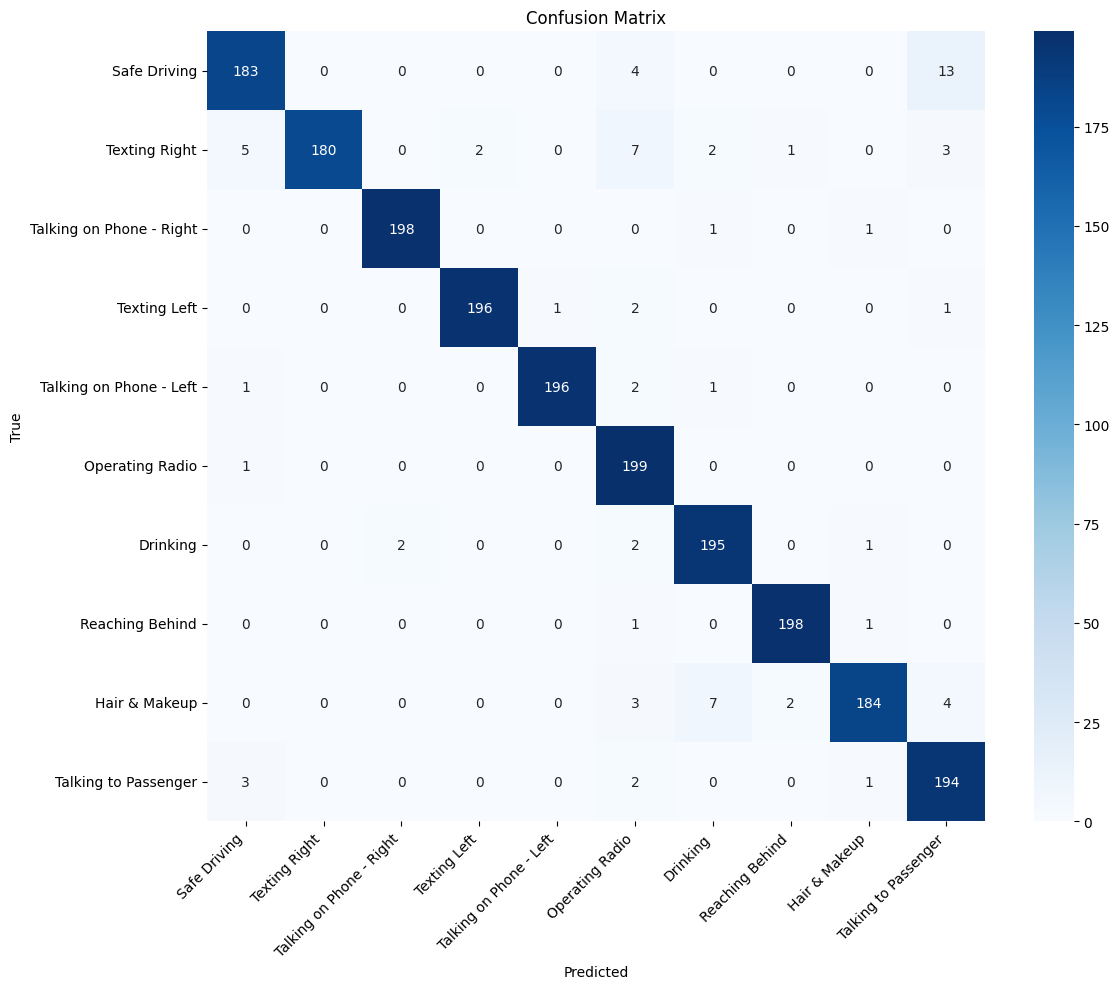


Normalized Confusion Matrix (percentages):


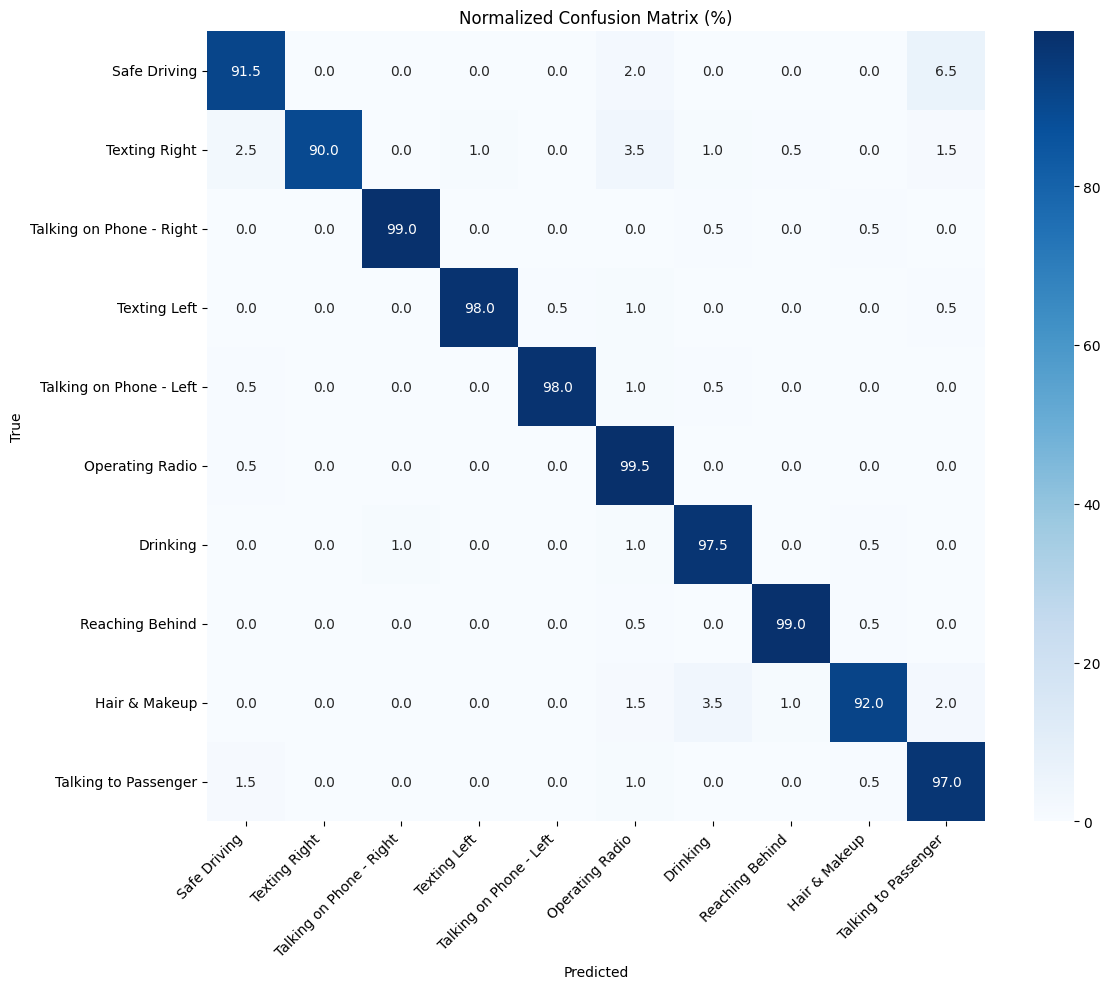

Safe Driving: 91.50%
Texting Right: 90.00%
Talking on Phone - Right: 99.00%
Texting Left: 98.00%
Talking on Phone - Left: 98.00%
Operating Radio: 99.50%
Drinking: 97.50%
Reaching Behind: 99.00%
Hair & Makeup: 92.00%
Talking to Passenger: 97.00%

Summary:
Evaluated Accuracy: 96.15%
F1-Score (Weighted Average): 96.16%
Precision (Weighted Average): 96.32%
Recall (Weighted Average): 96.15%

--- Performing K-Fold Cross-Validation with Transfer Learning ---

--- Fold 1/5 ---
Found 1600 images belonging to 10 classes.
Found 400 images belonging to 10 classes.


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 55s 543ms/step - accuracy: 0.1000 - loss: 3.2215 - val_accuracy: 0.1800 - val_loss: 2.2980 - learning_rate: 1.0000e-04
Epoch 2/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 26s 466ms/step - accuracy: 0.2144 - loss: 2.5470 - val_accuracy: 0.2400 - val_loss: 2.2347 - learning_rate: 1.0000e-04
Epoch 3/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 23s 461ms/step - accuracy: 0.2951 - loss: 2.1364 - val_accuracy: 0.2825 - val_loss: 2.1733 - learning_rate: 1.0000e-04
Epoch 4/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 23s 456ms/step - accuracy: 0.3669 - loss: 1.8717 - val_accuracy: 0.3300 - val_loss: 2.1446 - learning_rate: 1.0000e-04
Epoch 5/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 22s 442ms/step - accuracy: 0.5211 - loss: 1.4623 - val_accuracy: 0.3850 - val_loss: 1.9696 - learning_rate: 1.0000e-04
Epoch 6/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 41s 453ms/step - accuracy: 0.5834 - loss: 1.2413 - val_accuracy: 0.4475 - val_loss: 1.7023 - learning_rate: 1.0000e-04
Epoch 7/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 23s 456ms/step - acc

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 55s 539ms/step - accuracy: 0.1176 - loss: 3.2819 - val_accuracy: 0.1625 - val_loss: 2.3226 - learning_rate: 1.0000e-04
Epoch 2/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 23s 452ms/step - accuracy: 0.1949 - loss: 2.6880 - val_accuracy: 0.2175 - val_loss: 2.1969 - learning_rate: 1.0000e-04
Epoch 3/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 41s 457ms/step - accuracy: 0.2574 - loss: 2.3300 - val_accuracy: 0.3000 - val_loss: 2.0033 - learning_rate: 1.0000e-04
Epoch 4/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 41s 457ms/step - accuracy: 0.3401 - loss: 2.0606 - val_accuracy: 0.3825 - val_loss: 1.7939 - learning_rate: 1.0000e-04
Epoch 5/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 41s 456ms/step - accuracy: 0.4180 - loss: 1.6231 - val_accuracy: 0.4300 - val_loss: 1.6383 - learning_rate: 1.0000e-04
Epoch 6/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 23s 454ms/step - accuracy: 0.5391 - loss: 1.3711 - val_accuracy: 0.5025 - val_loss: 1.6002 - learning_rate: 1.0000e-04
Epoch 7/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 23s 456ms/step - acc

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 56s 548ms/step - accuracy: 0.1219 - loss: 3.2448 - val_accuracy: 0.1125 - val_loss: 2.4384 - learning_rate: 1.0000e-04
Epoch 2/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 24s 440ms/step - accuracy: 0.1997 - loss: 2.5794 - val_accuracy: 0.1825 - val_loss: 2.3805 - learning_rate: 1.0000e-04
Epoch 3/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 42s 461ms/step - accuracy: 0.2841 - loss: 2.2972 - val_accuracy: 0.2425 - val_loss: 2.2434 - learning_rate: 1.0000e-04
Epoch 4/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 40s 437ms/step - accuracy: 0.4333 - loss: 1.7335 - val_accuracy: 0.2125 - val_loss: 2.2968 - learning_rate: 1.0000e-04
Epoch 5/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 23s 454ms/step - accuracy: 0.4698 - loss: 1.5258 - val_accuracy: 0.2150 - val_loss: 2.4951 - learning_rate: 1.0000e-04
Epoch 6/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 22s 449ms/step - accuracy: 0.5963 - loss: 1.1902 - val_accuracy: 0.2525 - val_loss: 2.6035 - learning_rate: 1.0000e-04
Epoch 7/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 23s 451ms/step - acc

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 56s 560ms/step - accuracy: 0.0923 - loss: 3.3897 - val_accuracy: 0.1575 - val_loss: 2.3372 - learning_rate: 1.0000e-04
Epoch 2/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 22s 437ms/step - accuracy: 0.1766 - loss: 2.7386 - val_accuracy: 0.2350 - val_loss: 2.2664 - learning_rate: 1.0000e-04
Epoch 3/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 23s 448ms/step - accuracy: 0.2782 - loss: 2.2613 - val_accuracy: 0.2900 - val_loss: 2.1152 - learning_rate: 1.0000e-04
Epoch 4/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 41s 457ms/step - accuracy: 0.3776 - loss: 1.9362 - val_accuracy: 0.3175 - val_loss: 1.9979 - learning_rate: 1.0000e-04
Epoch 5/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 23s 454ms/step - accuracy: 0.5019 - loss: 1.5070 - val_accuracy: 0.3775 - val_loss: 1.8568 - learning_rate: 1.0000e-04
Epoch 6/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 23s 468ms/step - accuracy: 0.5719 - loss: 1.3131 - val_accuracy: 0.4400 - val_loss: 1.6014 - learning_rate: 1.0000e-04
Epoch 7/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 40s 452ms/step - acc

In [ ]:
# Load driver information
df_driver = pd.read_csv('/content/state_farm_dataset/driver_imgs_list.csv')

# Create a reduced dataset for faster experimentation
reduced_dataset_path = "/content/state_farm_dataset/reduced_train"
os.makedirs(reduced_dataset_path, exist_ok=True)

# Select a subset of images for each class
selected_images = df_driver.groupby("classname").apply(lambda x: x.sample(n=200, random_state=42)).reset_index(drop=True)

# Copy images to reduced dataset
original_train_path = "/content/state_farm_dataset/imgs/train"

for index, row in selected_images.iterrows():
    class_folder = row["classname"]
    img_name = row["img"]

    src = os.path.join(original_train_path, class_folder, img_name)
    dst_dir = os.path.join(reduced_dataset_path, class_folder)
    dst = os.path.join(dst_dir, img_name)

    os.makedirs(dst_dir, exist_ok=True)
    if os.path.exists(src):
        shutil.copy(src, dst)

print("✅ Dataset reduced successfully!")

# Define class names for reference
class_names = [
    "Safe Driving",
    "Texting Right",
    "Talking on Phone - Right",
    "Texting Left",
    "Talking on Phone - Left",
    "Operating Radio",
    "Drinking",
    "Reaching Behind",
    "Hair & Makeup",
    "Talking to Passenger"
]

# Classes dictionary
classes_dict = {
    0: "Safe Driving",
    1: "Texting Right",
    2: "Talking on Phone - Right",
    3: "Texting Left",
    4: "Talking on Phone - Left",
    5: "Operating Radio",
    6: "Drinking",
    7: "Reaching Behind",
    8: "Hair & Makeup",
    9: "Talking to Passenger"
}

# Define image dimensions
IMG_SIZE = 224  # Increased for MobileNetV2
BATCH_SIZE = 32

# Part 1: Visualize Dataset Distribution
def visualize_dataset_distribution(df, train_dir):
    class_counts = df['classname'].value_counts()
    plt.figure(figsize=(10, 5))
    plt.bar(class_counts.index, class_counts.values)
    plt.xlabel("Class")
    plt.ylabel("Number of Images")
    plt.title("Number of Images per Class")
    plt.xticks(rotation=45)
    plt.show()

    if 'subject' in df.columns:
        driver_counts = df['subject'].value_counts()
        plt.figure(figsize=(10, 5))
        plt.bar(driver_counts.index.astype(str), driver_counts.values)
        plt.xlabel("Driver")
        plt.ylabel("Number of Images")
        plt.title("Number of Images per Driver")
        plt.show()
    else:
        print("Column 'subject' not found. Skipping driver distribution plot.")

# Part 2: Preview Sample Images
def preview_training_images(data_dir, num_rows=3, num_cols=5):
    all_images = []
    all_labels = []
    classes = os.listdir(data_dir)
    for cls in classes:
        cls_dir = os.path.join(data_dir, cls)
        if os.path.isdir(cls_dir):
            imgs = os.listdir(cls_dir)
            for img in imgs:
                all_images.append(os.path.join(cls_dir, img))
                all_labels.append(cls)

    num_images = num_rows * num_cols
    indices = random.sample(range(len(all_images)), num_images)
    selected_images = [all_images[i] for i in indices]
    selected_labels = [all_labels[i] for i in indices]

    plt.figure(figsize=(15, 9))
    for i, (img_path, label) in enumerate(zip(selected_images, selected_labels)):
        img = Image.open(img_path)
        plt.subplot(num_rows, num_cols, i + 1)
        plt.imshow(img)
        plt.title(label)
        plt.axis("off")
    plt.tight_layout()
    plt.show()

# Part 3: Create Base CNN Model
def create_base_model(img_rows, img_cols, color_type):
    model = Sequential()

    # CNN Layer 1
    model.add(Conv2D(16, (3,3), activation='relu', input_shape=(img_rows, img_cols, color_type)))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2,2)))
    model.add(Dropout(0.3))

    # CNN Layer 2
    model.add(Conv2D(32, (3,3), activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2,2)))
    model.add(Dropout(0.3))

    # CNN Layer 3
    model.add(Conv2D(64, (3,3), activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2,2)))
    model.add(Dropout(0.3))

    # Fully Connected Layers
    model.add(Flatten())
    model.add(Dense(512, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(10, activation='softmax'))

    return model

# Part 4: Create Transfer Learning Model with MobileNetV2
def create_transfer_learning_model():
    # Load MobileNetV2 with pre-trained weights
    base_model = MobileNetV2(
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        include_top=False,
        weights='imagenet'
    )

    # Freeze base model layers
    #base_model.trainable = False
    base_model.trainable = True
    for layer in base_model.layers[:80]:  # Freeze fewer layers
        layer.trainable = False

    # Create the model
    model = Sequential([
        base_model,
        GlobalAveragePooling2D(),
        Dense(512, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        Dense(10, activation='softmax')
    ])

    return model

# Part 5: Hyperparameter Tuning Model Builder
def build_tunable_model(hp):
    # Load MobileNetV2 with pre-trained weights
    base_model = MobileNetV2(
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        include_top=False,
        weights='imagenet'
    )

    # Freeze base model layers
    base_model.trainable = False

    # Create the model
    model = Sequential()
    model.add(base_model)
    model.add(GlobalAveragePooling2D())

    # Tune number of dense layers and units
    for i in range(hp.Int('num_dense_layers', 1, 3)):
        model.add(Dense(
            units=hp.Int(f'dense_{i}_units', min_value=128, max_value=512, step=64),
            activation='relu'
        ))
        model.add(BatchNormalization())
        model.add(Dropout(hp.Float(f'dropout_{i}', min_value=0.2, max_value=0.5, step=0.1)))

    # Output layer
    model.add(Dense(10, activation='softmax'))

    # Tune learning rate
    learning_rate = hp.Choice('learning_rate', values=[1e-4, 5e-4, 1e-3, 5e-3])

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# Part 6: Plot Training History
def plot_training_history(history):
    fig, ax = plt.subplots(ncols=2, nrows=1, figsize=(12, 5))
    ax[0].plot(history.history['loss'], label='Training')
    ax[0].plot(history.history['val_loss'], label='Validation')
    ax[0].set_xlabel('Epochs')
    ax[0].set_ylabel('Loss')
    ax[0].legend()
    ax[0].set_title('Training & Validation Loss')

    ax[1].plot(history.history['accuracy'], label='Training')
    ax[1].plot(history.history['val_accuracy'], label='Validation')
    ax[1].set_xlabel('Epochs')
    ax[1].set_ylabel('Accuracy')
    ax[1].legend()
    ax[1].set_title('Training & Validation Accuracy')

    plt.tight_layout()
    plt.show()

# Part 7: Print Evaluation Metrics
def print_evaluation_metrics(y_true, y_pred):
    # Calculate and display accuracy
    acc = accuracy_score(y_true, y_pred)
    print(f"\nAccuracy: {acc*100:.2f}%")

    # Generate detailed classification report
    print("\nDetailed Classification Report:")
    report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
    report_df = pd.DataFrame(report).transpose()

    # Convert decimal values to percentages
    percent_df = report_df.copy()
    for col in ['precision', 'recall', 'f1-score']:
        percent_df[col] = percent_df[col] * 100

    print(percent_df.round(2).to_string())

    # Create and plot confusion matrix
    print("\nGenerating confusion matrix...")
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    # Calculate normalized confusion matrix
    print("\nNormalized Confusion Matrix (percentages):")
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm_norm, annot=True, fmt='.1f', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Normalized Confusion Matrix (%)')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    # Calculate per-class accuracy
    per_class_acc = cm.diagonal() / cm.sum(axis=1) * 100
    for i, class_name in enumerate(class_names):
        print(f"{class_name}: {per_class_acc[i]:.2f}%")

    # Print summary
    print("\nSummary:")
    print(f"Evaluated Accuracy: {acc*100:.2f}%")
    print(f"F1-Score (Weighted Average): {report['weighted avg']['f1-score']*100:.2f}%")
    print(f"Precision (Weighted Average): {report['weighted avg']['precision']*100:.2f}%")
    print(f"Recall (Weighted Average): {report['weighted avg']['recall']*100:.2f}%")

# Part 8: K-Fold Cross-Validation
def perform_kfold_validation(model_type='transfer', n_splits=5):
    # Create a directory to store images for K-Fold validation
    kfold_data_dir = '/content/state_farm_dataset/kfold_data'
    os.makedirs(kfold_data_dir, exist_ok=True)

    # Copy images to K-Fold directory
    for class_name in os.listdir(reduced_dataset_path):
        class_dir = os.path.join(reduced_dataset_path, class_name)
        if os.path.isdir(class_dir):
            kfold_class_dir = os.path.join(kfold_data_dir, class_name)
            os.makedirs(kfold_class_dir, exist_ok=True)
            for img_name in os.listdir(class_dir):
                src = os.path.join(class_dir, img_name)
                dst = os.path.join(kfold_class_dir, img_name)
                if not os.path.exists(dst):
                    shutil.copy(src, dst)

    # Get all image paths and labels
    all_images = []
    all_labels = []
    for class_idx, class_name in enumerate(sorted(os.listdir(kfold_data_dir))):
        class_dir = os.path.join(kfold_data_dir, class_name)
        if os.path.isdir(class_dir):
            for img_name in os.listdir(class_dir):
                all_images.append(os.path.join(class_dir, img_name))
                all_labels.append(class_idx)

    # Convert to numpy arrays
    all_images = np.array(all_images)
    all_labels = np.array(all_labels)

    # Initialize KFold
    kfold = KFold(n_splits=n_splits, shuffle=True, random_state=42)

    # For storing metrics
    fold_accuracies = []
    fold_val_accuracies = []

    # Initialize figure for plotting loss and accuracy
    fig, axes = plt.subplots(n_splits, 2, figsize=(15, n_splits*5))

    # Initialize callbacks
    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    )

    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=5,
        min_lr=1e-6
    )

    # Loop through each fold
    for fold, (train_indices, val_indices) in enumerate(kfold.split(all_images)):
        print(f"\n--- Fold {fold+1}/{n_splits} ---")

        # Get training and validation data for this fold
        X_train, X_val = all_images[train_indices], all_images[val_indices]
        y_train, y_val = all_labels[train_indices], all_labels[val_indices]

        # Create directories for this fold
        fold_train_dir = f'/content/state_farm_dataset/fold_{fold+1}_train'
        fold_val_dir = f'/content/state_farm_dataset/fold_{fold+1}_val'

        os.makedirs(fold_train_dir, exist_ok=True)
        os.makedirs(fold_val_dir, exist_ok=True)

        # Clear previous fold directories
        for d in [fold_train_dir, fold_val_dir]:
            for class_name in os.listdir(kfold_data_dir):
                os.makedirs(os.path.join(d, class_name), exist_ok=True)

        # Copy training images to fold directory
        for img_path, label in zip(X_train, y_train):
            class_name = f'c{label}'
            dst_dir = os.path.join(fold_train_dir, class_name)
            os.makedirs(dst_dir, exist_ok=True)
            dst = os.path.join(dst_dir, os.path.basename(img_path))
            shutil.copy(img_path, dst)

        # Copy validation images to fold directory
        for img_path, label in zip(X_val, y_val):
            class_name = f'c{label}'
            dst_dir = os.path.join(fold_val_dir, class_name)
            os.makedirs(dst_dir, exist_ok=True)
            dst = os.path.join(dst_dir, os.path.basename(img_path))
            shutil.copy(img_path, dst)

        # Create data generators
        train_datagen = ImageDataGenerator(
            rescale=1./255,
            rotation_range=20,
            width_shift_range=0.2,
            height_shift_range=0.2,
            shear_range=0.2,
            zoom_range=0.2,
            horizontal_flip=True,
            fill_mode='nearest'
        )

        val_datagen = ImageDataGenerator(rescale=1./255)

        train_generator = train_datagen.flow_from_directory(
            fold_train_dir,
            target_size=(IMG_SIZE, IMG_SIZE),
            batch_size=BATCH_SIZE,
            class_mode='categorical'
        )

        val_generator = val_datagen.flow_from_directory(
            fold_val_dir,
            target_size=(IMG_SIZE, IMG_SIZE),
            batch_size=BATCH_SIZE,
            class_mode='categorical'
        )

        # Create model based on model_type
        if model_type == 'transfer':
            model = create_transfer_learning_model()
        else:
            model = create_base_model(IMG_SIZE, IMG_SIZE, 3)

        # Compile model
        model.compile(
            optimizer=Adam(learning_rate=1e-4),
            loss='categorical_crossentropy',
            metrics=['accuracy']
        )

        # Train model
        history = model.fit(
            train_generator,
            epochs=30,
            validation_data=val_generator,
            callbacks=[early_stopping, reduce_lr]
        )

        # Store metrics
        fold_accuracies.append(max(history.history['accuracy']))
        fold_val_accuracies.append(max(history.history['val_accuracy']))

        # Plot training history for this fold
        axes[fold, 0].plot(history.history['loss'], label='Training')
        axes[fold, 0].plot(history.history['val_loss'], label='Validation')
        axes[fold, 0].set_title(f'Fold {fold+1} Loss')
        axes[fold, 0].set_xlabel('Epochs')
        axes[fold, 0].set_ylabel('Loss')
        axes[fold, 0].legend()

        axes[fold, 1].plot(history.history['accuracy'], label='Training')
        axes[fold, 1].plot(history.history['val_accuracy'], label='Validation')
        axes[fold, 1].set_title(f'Fold {fold+1} Accuracy')
        axes[fold, 1].set_xlabel('Epochs')
        axes[fold, 1].set_ylabel('Accuracy')
        axes[fold, 1].legend()

        # Evaluate model on validation set
        print(f"\nEvaluating fold {fold+1}...")

        val_generator.reset()
        y_true = val_generator.classes
        steps = len(val_generator)

        y_pred_probs = model.predict(val_generator, steps=steps)
        y_pred = np.argmax(y_pred_probs, axis=1)

        # Print classification report for this fold
        print(f"Fold {fold+1} Classification Report:")
        print(classification_report(y_true, y_pred, target_names=class_names))

        # Clean up fold directories to save space
        shutil.rmtree(fold_train_dir)
        shutil.rmtree(fold_val_dir)

    # Adjust layout and show plots
    plt.tight_layout()
    plt.savefig('kfold_history.png')
    plt.show()

    # Print summary of all folds
    print("\n--- K-Fold Cross-Validation Summary ---")
    for fold in range(n_splits):
        print(f"Fold {fold+1}: Training Accuracy = {fold_accuracies[fold]*100:.2f}%, Validation Accuracy = {fold_val_accuracies[fold]*100:.2f}%")

    print(f"\nAverage Training Accuracy: {np.mean(fold_accuracies)*100:.2f}%")
    print(f"Average Validation Accuracy: {np.mean(fold_val_accuracies)*100:.2f}%")
    print(f"Standard Deviation of Validation Accuracy: {np.std(fold_val_accuracies)*100:.2f}%")

    return np.mean(fold_val_accuracies)

# Part 9: Hyperparameter Tuning with Keras Tuner
def perform_hyperparameter_tuning():
    print("\n--- Starting Hyperparameter Tuning ---")

    # Create data generators
    datagen = ImageDataGenerator(
        rescale=1./255,
        rotation_range=20,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True,
        validation_split=0.2
    )

    train_gen = datagen.flow_from_directory(
        reduced_dataset_path,
        target_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        subset='training'
    )

    val_gen = datagen.flow_from_directory(
        reduced_dataset_path,
        target_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        subset='validation'
    )

    # Create the tuner
    tuner = kt.RandomSearch(
        build_tunable_model,
        objective='val_accuracy',
        max_trials=10,
        executions_per_trial=1,
        directory='hyperparameter_tuning',
        project_name='distracted_driver'
    )

    # Create callbacks for early stopping
    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    )

    # Search for best hyperparameters
    tuner.search(
        train_gen,
        epochs=15,
        validation_data=val_gen,
        callbacks=[early_stopping]
    )

    # Get best hyperparameters
    best_hps = tuner.get_best_hyperparameters(1)[0]
    print("\nBest Hyperparameters:")
    print(f"Learning Rate: {best_hps.get('learning_rate')}")
    print(f"Number of Dense Layers: {best_hps.get('num_dense_layers')}")

    for i in range(best_hps.get('num_dense_layers')):
        print(f"Dense Layer {i+1} Units: {best_hps.get(f'dense_{i}_units')}")
        print(f"Dropout {i+1} Rate: {best_hps.get(f'dropout_{i}')}")

    # Build best model
    best_model = tuner.hypermodel.build(best_hps)

    # Train best model
    history = best_model.fit(
        train_gen,
        epochs=30,
        validation_data=val_gen,
        callbacks=[early_stopping]
    )

    # Plot training history
    plot_training_history(history)

    return best_model, history

# Part 10: Fine-tune Transfer Learning Model
def fine_tune_transfer_model(model):
    print("\n--- Fine-tuning Transfer Learning Model ---")

    # Create data generators with augmentation
    datagen = ImageDataGenerator(
        rescale=1./255,
        rotation_range=20,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True,
        validation_split=0.2
    )

    train_gen = datagen.flow_from_directory(
        reduced_dataset_path,
        target_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        subset='training'
    )

    val_gen = datagen.flow_from_directory(
        reduced_dataset_path,
        target_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        subset='validation'
    )

    # Unfreeze some layers of the base model
    base_model = model.layers[0]
    base_model.trainable = True

    # Freeze first 100 layers, unfreeze the rest
    for layer in base_model.layers[:100]:
        layer.trainable = False

    # Recompile model with lower learning rate
    model.compile(
        optimizer=Adam(learning_rate=1e-5),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    # Create callbacks
    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    )

    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=5,
        min_lr=1e-6
    )

    # Fine-tune model
    history = model.fit(
        train_gen,
        epochs=30,
        validation_data=val_gen,
        callbacks=[early_stopping, reduce_lr]
    )

    # Plot training history
    plot_training_history(history)

    return model, history

# Part 11: Evaluate Model
def evaluate_model(model, display_results=True):
    # Create data generator
    datagen = ImageDataGenerator(rescale=1./255)

    # Generate validation data
    val_gen = datagen.flow_from_directory(
        reduced_dataset_path,
        target_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        shuffle=False
    )

    # Evaluate model on validation set
    val_gen.reset()
    y_true = val_gen.classes
    steps = len(val_gen)

    y_pred_probs = model.predict(val_gen, steps=steps)
    y_pred = np.argmax(y_pred_probs, axis=1)

    # Print evaluation metrics
    if display_results:
        print_evaluation_metrics(y_true, y_pred)

    # Calculate accuracy
    acc = accuracy_score(y_true, y_pred)

    return acc

# Part 12: Visualize Model Architecture
def visualize_model_architecture(model):
    try:
        visualkeras.layered_view(model, legend=True).show()
        tf.keras.utils.plot_model(
            model,
            to_file='model_architecture.png',
            show_shapes=True,
            show_layer_names=True,
            rankdir='TB',
            expand_nested=True,
            dpi=96
        )
        print("Model architecture visualized and saved as 'model_architecture.png'")
    except Exception as e:
        print(f"Error visualizing model architecture: {e}")



# Main execution flow
def main():
    # ✅ Save and download untrained model for UI testing
    #print("\n--- Saving Untrained Model for UI Testing ---")
    #model = create_transfer_learning_model()
    #model.save("best_driver_detection_model.keras")

    #from google.colab import files
    #files.download("best_driver_detection_model.keras")
    #return  # Skip rest of main for this test
    #print("Starting Enhanced Distracted Driver Detection...")

    # 1. Visualize dataset distribution
    visualize_dataset_distribution(df_driver, reduced_dataset_path)

    # 2. Preview sample images
    preview_training_images(reduced_dataset_path)

    # 3. Create a transfer learning model with MobileNetV2
    print("\n--- Creating Transfer Learning Model with MobileNetV2 ---")
    transfer_model = create_transfer_learning_model()
    transfer_model.compile(
        optimizer=Adam(learning_rate=1e-4),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    # Create data generators with augmentation for transfer learning
    datagen = ImageDataGenerator(
        rescale=1./255,
        rotation_range=20,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.2,
        zoom_range=0.3,
        brightness_range=[0.7, 1.3],
        horizontal_flip=True,
        validation_split=0.2
    )

    train_gen = datagen.flow_from_directory(
        reduced_dataset_path,
        target_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        subset='training'
    )

    val_gen = datagen.flow_from_directory(
        reduced_dataset_path,
        target_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        subset='validation'
    )

    # Train the transfer learning model
    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    )

    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=5,
        min_lr=1e-6
    )

    # Train transfer learning model
    class_weight = {i: 1.0 for i in range(10)}
    class_weight[8] = 2.5
    transfer_history = transfer_model.fit(
        train_gen,
        epochs=30,
        validation_data=val_gen,
        callbacks=[early_stopping, reduce_lr]
    )

    # Plot training history
    plot_training_history(transfer_history)

    # Evaluate transfer learning model
    print("\n--- Evaluating Transfer Learning Model ---")
    transfer_accuracy = evaluate_model(transfer_model)

    # 4. Perform K-Fold Cross-Validation with transfer learning
    print("\n--- Performing K-Fold Cross-Validation with Transfer Learning ---")
    kfold_accuracy = perform_kfold_validation(model_type='transfer', n_splits=5)

    # 5. Hyperparameter Tuning
    best_model, tuning_history = perform_hyperparameter_tuning()

    # Evaluate best model from hyperparameter tuning
    print("\n--- Evaluating Best Model from Hyperparameter Tuning ---")
    best_model_accuracy = evaluate_model(best_model)

    # 6. Fine-tune transfer learning model
    fine_tuned_model, fine_tuning_history = fine_tune_transfer_model(transfer_model)

    # Evaluate fine-tuned model
    print("\n--- Evaluating Fine-Tuned Model ---")
    fine_tuned_accuracy = evaluate_model(fine_tuned_model)

    # 7. Visualize model architecture
    print("\n--- Visualizing Model Architecture ---")
    visualize_model_architecture(fine_tuned_model)

    # 8. Compare all models
    print("\n--- Model Comparison ---")
    print(f"Transfer Learning Model Accuracy: {transfer_accuracy*100:.2f}%")
    print(f"K-Fold Cross-Validation Average Accuracy: {kfold_accuracy*100:.2f}%")
    print(f"Best Model from Hyperparameter Tuning Accuracy: {best_model_accuracy*100:.2f}%")
    print(f"Fine-Tuned Model Accuracy: {fine_tuned_accuracy*100:.2f}%")

    # 9. Save the best model
    print("\n--- Saving Best Model ---")
    best_overall_model = fine_tuned_model  # Assuming fine-tuned model is the best
    best_overall_model.save("best_driver_detection_model.keras")

    # Trigger model download in Colab
    from google.colab import files
    files.download("best_driver_detection_model.keras")

    # Allow prediction on uploaded images
    # print("\n--- Test the model on your own images ---")
    # print("Upload an image to predict the driver's state:")
    # predict_single_image(best_overall_model)

    print("\nEnhanced Distracted Driver Detection completed successfully!")

# Run the main function
if __name__ == "__main__":
    main()

In [ ]:
import matplotlib.pyplot as plt

# Step 1: Replace these values after tomorrow’s run
# (Update them with the latest values printed after each model evaluation)
transfer_learning_acc = 75.90
fine_tuned_acc = 78.35
hyperparam_tuned_acc = 81.55
kfold_avg_acc = 72.90

# Step 2: Prepare data
model_names = [
    "Transfer Learning",
    "Fine-Tuned Model",
    "Hyperparameter Tuned",
    "K-Fold Avg Model"
]
accuracies = [
    transfer_learning_acc,
    fine_tuned_acc,
    hyperparam_tuned_acc,
    kfold_avg_acc
]

# Step 3: Plot bar chart
plt.figure(figsize=(10, 6))
bars = plt.bar(model_names, accuracies, color=['royalblue', 'goldenrod', 'seagreen', 'tomato'])

# Step 4: Annotate bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.5, f'{height:.2f}%', ha='center', fontsize=10)

plt.title("Model Accuracy Comparison", fontsize=14)
plt.ylabel("Accuracy (%)", fontsize=12)
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Step 5: Save & show
plt.savefig("model_accuracy_comparison.png")
plt.show()


In [ ]:
# Run this cell separately to upload and classify an image
# Make sure the model has been trained and saved first

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
from google.colab import files
from PIL import Image
import io

# Define class names
class_names = [
    "Safe Driving",
    "Texting Right",
    "Talking on Phone - Right",
    "Texting Left",
    "Talking on Phone - Left",
    "Operating Radio",
    "Drinking",
    "Reaching Behind",
    "Hair & Makeup",
    "Talking to Passenger"
]

def predict_uploaded_image():
    try:
        # Try to load the saved model first
        try:
            model = load_model("best_driver_detection_model.keras")
            print("Model loaded from saved file successfully!")
        except:
            print("Saved model not found. Creating a new model...")
            # If saved model doesn't exist, create and use the transfer learning model
            from tensorflow.keras.applications import MobileNetV2
            from tensorflow.keras.models import Sequential
            from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, BatchNormalization, Dropout
            from tensorflow.keras.optimizers import Adam

            # Create the same model architecture as in main code
            base_model = MobileNetV2(
                input_shape=(224, 224, 3),
                include_top=False,
                weights='imagenet'
            )

            base_model.trainable = True
            for layer in base_model.layers[:80]:
                layer.trainable = False

            model = Sequential([
                base_model,
                GlobalAveragePooling2D(),
                Dense(512, activation='relu'),
                BatchNormalization(),
                Dropout(0.5),
                Dense(256, activation='relu'),
                BatchNormalization(),
                Dropout(0.3),
                Dense(10, activation='softmax')
            ])

            model.compile(
                optimizer=Adam(learning_rate=1e-4),
                loss='categorical_crossentropy',
                metrics=['accuracy']
            )

            print("New model created! Note: This model is not trained yet.")
            print("For best results, please run the main training script first.")

        # Upload image
        print("\nPlease upload an image file:")
        uploaded = files.upload()

        for filename in uploaded.keys():
            print(f"\nProcessing image: {filename}")

            # Load and preprocess the image
            img_data = uploaded[filename]
            img = Image.open(io.BytesIO(img_data))

            # Display original image
            plt.figure(figsize=(10, 5))
            plt.subplot(1, 2, 1)
            plt.imshow(img)
            plt.title("Original Image")
            plt.axis('off')

            # Preprocess image
            img = img.convert('RGB')
            img = img.resize((224, 224))
            img_array = image.img_to_array(img)
            img_array = np.expand_dims(img_array, axis=0)
            img_array = img_array / 255.0

            # Make prediction
            predictions = model.predict(img_array)
            predicted_class = np.argmax(predictions[0])
            confidence = predictions[0][predicted_class] * 100

            # Display results
            plt.subplot(1, 2, 2)
            plt.barh(class_names, predictions[0] * 100)
            plt.xlabel('Confidence (%)')
            plt.title('Prediction Probabilities')
            plt.tight_layout()
            plt.show()

            # Print prediction
            print(f"\nPrediction: {class_names[predicted_class]}")
            print(f"Confidence: {confidence:.2f}%")

            # Print top 3 predictions
            print("\nTop 3 predictions:")
            top_3_indices = np.argsort(predictions[0])[-3:][::-1]
            for i, idx in enumerate(top_3_indices):
                print(f"{i+1}. {class_names[idx]}: {predictions[0][idx]*100:.2f}%")

    except Exception as e:
        print(f"Error: {e}")
        print("\nTroubleshooting tips:")
        print("1. Make sure you've run the main training script first")
        print("2. Check if 'best_driver_detection_model.keras' file exists in the current directory")
        print("3. If the model file doesn't exist, the script will create an untrained model")
        print("4. For best results, please complete the training process first")

# Run the prediction function
predict_uploaded_image()